# SOR Electrostatics and Biot–Savart Quadrature

Jacobi versus successive over-relaxation scaling, a point charge in a grounded box, and straight-wire magnetic-field integration.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Problem 1: Capacitor with Jacobi and SOR

Half plate height a (e.g. 0.25): 0.25
Half plate separation b (e.g. 0.10): 0.1
Grid spacing dL for representative plot (e.g. 0.02): 0.02
Convergence threshold acc (e.g. 1e-5): 0.00001

=== Representative SOR run ===
N = 51, dL = 0.020000
SOR iterations    = 85
Final average |ΔV| = 9.127e-06
SOR alpha used     = 1.883949


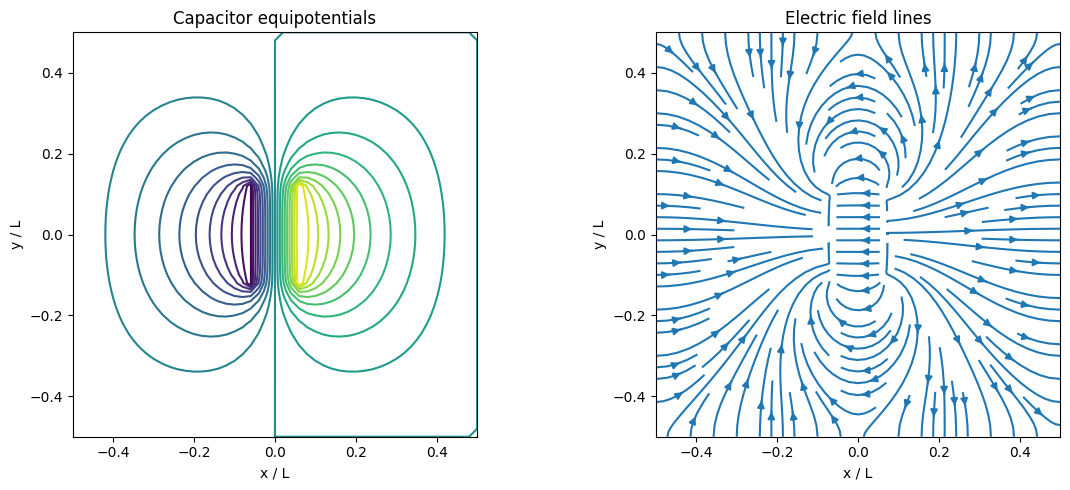


=== Scaling Study ===
dL	N	Jacobi	SOR	alpha
0.05000	21	184	36	1.73974
0.04000	27	286	45	1.79154
0.03000	35	427	59	1.83527
0.02500	41	562	69	1.85766
0.02000	51	780	85	1.88395
0.01500	67	1204	109	1.91042


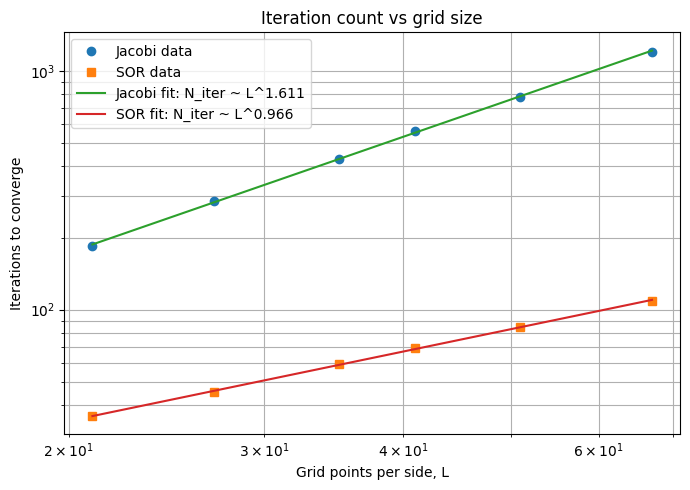


=== Power-law fits ===
Jacobi: N_iter ≈ 1.3890e+00 * L^1.6114
SOR:    N_iter ≈ 1.8937e+00 * L^0.9659

=== Summary table ===
L	Jacobi	SOR	alpha
21	184	36	1.73974
27	286	45	1.79154
35	427	59	1.83527
41	562	69	1.85766
51	780	85	1.88395
67	1204	109	1.91042


In [ ]:
# Problem 1 - PHYS 580 HW
# Capacitor problem solved with Jacobi and SOR
# Compares N_iter vs grid size L and shows:
#   Jacobi: N_iter ~ L^2
#   SOR:    N_iter ~ L
#
# Geometry:
#   Outer square box boundary at V = 0
#   Two finite vertical plates inside the box at V = -1 and V = +1
#
# What this code does:
#   1. Solves the capacitor once with Jacobi and once with SOR
#   2. Computes the electric field from the converged potential
#   3. Plots equipotentials and field lines
#   4. Sweeps over grid sizes and compares iteration counts
#   5. Fits log-log slopes to verify the expected scaling laws
#
# Numerical approximation:
#   - 2D Laplace equation on a square lattice
#   - second derivatives replaced by nearest-neighbor finite differences
#   - Jacobi: uses old grid to compute a new grid
#   - SOR: uses Gauss-Seidel update with over-relaxation parameter alpha
#   - convergence test: average absolute change in V per sweep < acc
#
# Adequacy check:
#   - same convergence threshold used for both methods
#   - multiple grid sizes used
#   - log-log fit of N_iter vs L tests the expected asymptotic behavior

import numpy as np
import matplotlib.pyplot as plt
from math import floor, pi


# ------------------------------------------------------------
# Geometry and boundary conditions
# ------------------------------------------------------------
def setup_grid(a, b, dL_in):
    """
    Build a square grid over -0.5 <= x,y <= 0.5

    a = half plate height in units of box size L_box
        (plate extends from y = -a to y = +a)
    b = half plate separation in units of box size L_box
        (plates sit at x = -b and x = +b)
    dL_in = desired grid spacing

    Returns:
        V      initial potential array
        X, Y   coordinate arrays
        params dict with geometry info
    """
    M = floor(0.5 / dL_in + 0.5)
    dL = 1.0 / (2 * M)
    N = 2 * M + 1

    aM = floor(a * M + 0.5)
    bM = floor(b * M + 0.5)

    xvals = np.array([-0.5 + j * dL for j in range(N)])
    yvals = np.array([-0.5 + i * dL for i in range(N)])
    X, Y = np.meshgrid(xvals, yvals, indexing="xy")

    V = np.zeros((N, N), dtype=float)

    params = {
        "M": M,
        "N": N,
        "dL": dL,
        "aM": aM,
        "bM": bM,
        "a": a,
        "b": b
    }

    apply_boundary_conditions(V, params)
    return V, X, Y, params


def apply_boundary_conditions(V, params):
    """
    Outer box boundary: V = 0
    Left plate:  V = -1
    Right plate: V = +1
    """
    M = params["M"]
    aM = params["aM"]
    bM = params["bM"]

    # outer boundary = 0
    V[0, :] = 0.0
    V[-1, :] = 0.0
    V[:, 0] = 0.0
    V[:, -1] = 0.0

    # capacitor plates
    xL = M - bM
    xR = M + bM
    y_min = M - aM
    y_max = M + aM

    for i in range(y_min, y_max + 1):
        V[i, xL] = -1.0
        V[i, xR] = +1.0


def is_plate_point(i, j, params):
    M = params["M"]
    aM = params["aM"]
    bM = params["bM"]

    xL = M - bM
    xR = M + bM
    y_min = M - aM
    y_max = M + aM

    return ((j == xL or j == xR) and (y_min <= i <= y_max))


# ------------------------------------------------------------
# Jacobi method
# ------------------------------------------------------------
def update_jacobi(V, params):
    ny, nx = V.shape
    Vnew = V.copy()

    # Re-apply fixed boundaries and plates
    apply_boundary_conditions(Vnew, params)

    delta = 0.0
    count = 0

    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            if is_plate_point(i, j, params):
                continue

            old = V[i, j]
            Vnew[i, j] = 0.25 * (
                V[i - 1, j] + V[i + 1, j] +
                V[i, j - 1] + V[i, j + 1]
            )

            delta += abs(Vnew[i, j] - old)
            count += 1

    delta /= max(count, 1)
    return Vnew, delta


def solve_jacobi(V0, params, acc=1e-5, max_iter=2_000_000, record_history=False):
    V = V0.copy()
    history = []
    delta = np.inf
    it = 0

    while delta > acc and it < max_iter:
        V, delta = update_jacobi(V, params)
        it += 1

        if record_history and (it <= 50 or it % 10 == 0):
            history.append((it, delta))

    return V, it, delta, history


# ------------------------------------------------------------
# SOR method
# ------------------------------------------------------------
def alpha_optimal(N):
    """
    Approximate optimal SOR parameter for a square LxL grid with fixed boundaries.
    Lecture/textbook estimate:
        alpha ~ 2 / (1 + pi/L)
    Here we use N as the number of grid points per side.
    """
    return 2.0 / (1.0 + pi / N)


def update_sor(V, params, alpha):
    ny, nx = V.shape

    apply_boundary_conditions(V, params)

    delta = 0.0
    count = 0

    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            if is_plate_point(i, j, params):
                continue

            old = V[i, j]

            v_gs = 0.25 * (
                V[i - 1, j] + V[i + 1, j] +
                V[i, j - 1] + V[i, j + 1]
            )

            V[i, j] = old + alpha * (v_gs - old)

            delta += abs(V[i, j] - old)
            count += 1

    apply_boundary_conditions(V, params)
    delta /= max(count, 1)
    return delta


def solve_sor(V0, params, acc=1e-5, alpha=None, max_iter=2_000_000, record_history=False):
    V = V0.copy()
    if alpha is None:
        alpha = alpha_optimal(params["N"])

    history = []
    delta = np.inf
    it = 0

    while delta > acc and it < max_iter:
        delta = update_sor(V, params, alpha)
        it += 1

        if record_history and (it <= 50 or it % 10 == 0):
            history.append((it, delta))

    return V, it, delta, history, alpha


# ------------------------------------------------------------
# Electric field
# ------------------------------------------------------------
def compute_E(V, params):
    dL = params["dL"]
    ny, nx = V.shape

    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)

    # central differences in the interior
    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dL)
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dL)

    # one-sided on boundaries
    Ex[:, 0] = -(V[:, 1] - V[:, 0]) / dL
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dL

    Ey[0, :] = -(V[1, :] - V[0, :]) / dL
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dL

    return Ex, Ey


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_solution(V, X, Y, Ex, Ey, params, method_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # potential colormap
    im = axes[0].imshow(
        V,
        origin="lower",
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        aspect="equal"
    )
    axes[0].set_title(f"{method_name}: Potential")
    axes[0].set_xlabel("x / L")
    axes[0].set_ylabel("y / L")
    plt.colorbar(im, ax=axes[0], label="V")

    # equipotentials
    axes[1].contour(X, Y, V, levels=21)
    axes[1].set_title(f"{method_name}: Equipotentials")
    axes[1].set_xlabel("x / L")
    axes[1].set_ylabel("y / L")
    axes[1].set_aspect("equal", adjustable="box")

    # field lines
    axes[2].streamplot(X, Y, Ex, Ey, density=1.2)
    axes[2].set_title(f"{method_name}: Electric field")
    axes[2].set_xlabel("x / L")
    axes[2].set_ylabel("y / L")
    axes[2].set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()


def plot_convergence(history_j, history_s, title_suffix=""):
    if len(history_j) == 0 and len(history_s) == 0:
        return

    plt.figure(figsize=(7, 5))

    if len(history_j) > 0:
        it_j = [p[0] for p in history_j]
        d_j = [p[1] for p in history_j]
        plt.semilogy(it_j, d_j, label="Jacobi")

    if len(history_s) > 0:
        it_s = [p[0] for p in history_s]
        d_s = [p[1] for p in history_s]
        plt.semilogy(it_s, d_s, label="SOR")

    plt.xlabel("Iteration")
    plt.ylabel("Average |ΔV|")
    plt.title(f"Convergence history {title_suffix}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Scaling study
# ------------------------------------------------------------
def scaling_study(a, b, dL_list, acc=1e-5, alpha_mode="optimal"):
    """
    For each grid size, solve with Jacobi and SOR and record iteration counts.
    """
    Nvals = []
    jacobi_iters = []
    sor_iters = []
    alphas = []

    print("\n=== Scaling Study ===")
    print("dL\tN\tJacobi\tSOR\talpha")

    for dL_in in dL_list:
        V0, _, _, params = setup_grid(a, b, dL_in)

        # Jacobi
        _, it_j, _, _ = solve_jacobi(V0, params, acc=acc)

        # SOR
        if alpha_mode == "optimal":
            alpha = alpha_optimal(params["N"])
        else:
            alpha = float(alpha_mode)

        _, it_s, _, _, alpha_used = solve_sor(V0, params, acc=acc, alpha=alpha)

        Nvals.append(params["N"])
        jacobi_iters.append(it_j)
        sor_iters.append(it_s)
        alphas.append(alpha_used)

        print(f"{dL_in:.5f}\t{params['N']}\t{it_j}\t{it_s}\t{alpha_used:.5f}")

    return (
        np.array(Nvals, dtype=float),
        np.array(jacobi_iters, dtype=float),
        np.array(sor_iters, dtype=float),
        np.array(alphas, dtype=float)
    )


def fit_power_law(x, y):
    """
    Fit y = A x^m using log-log linear regression.
    Returns slope m and prefactor A.
    """
    logx = np.log(x)
    logy = np.log(y)
    m, c = np.polyfit(logx, logy, 1)
    A = np.exp(c)
    return m, A


def plot_scaling(Nvals, jacobi_iters, sor_iters):
    m_j, A_j = fit_power_law(Nvals, jacobi_iters)
    m_s, A_s = fit_power_law(Nvals, sor_iters)

    xfit = np.linspace(np.min(Nvals), np.max(Nvals), 300)
    yfit_j = A_j * xfit**m_j
    yfit_s = A_s * xfit**m_s

    plt.figure(figsize=(7, 5))
    plt.loglog(Nvals, jacobi_iters, "o", label="Jacobi data")
    plt.loglog(Nvals, sor_iters, "s", label="SOR data")
    plt.loglog(xfit, yfit_j, "-", label=f"Jacobi fit: N_iter ~ L^{m_j:.3f}")
    plt.loglog(xfit, yfit_s, "-", label=f"SOR fit: N_iter ~ L^{m_s:.3f}")

    plt.xlabel("Grid points per side, L")
    plt.ylabel("Iterations to converge")
    plt.title("Iteration count vs grid size")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n=== Power-law fits ===")
    print(f"Jacobi: N_iter ≈ {A_j:.4e} * L^{m_j:.4f}")
    print(f"SOR:    N_iter ≈ {A_s:.4e} * L^{m_s:.4f}")

    return (m_j, A_j), (m_s, A_s)


# ------------------------------------------------------------
# Optional alpha scan for one grid
# ------------------------------------------------------------
def scan_alpha_for_sor(a, b, dL_in, acc=1e-5, alpha_values=None):
    if alpha_values is None:
        alpha_values = np.linspace(1.0, 1.95, 20)

    V0, _, _, params = setup_grid(a, b, dL_in)

    iters = []
    for alpha in alpha_values:
        _, it_s, _, _, _ = solve_sor(V0, params, acc=acc, alpha=alpha)
        iters.append(it_s)

    iters = np.array(iters)

    plt.figure(figsize=(7, 5))
    plt.plot(alpha_values, iters, "o-")
    plt.xlabel("SOR parameter alpha")
    plt.ylabel("Iterations to converge")
    plt.title(f"SOR alpha scan (N = {params['N']}, acc = {acc:g})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    idx = np.argmin(iters)
    print("\n=== SOR alpha scan ===")
    print(f"Best alpha in scan = {alpha_values[idx]:.4f}")
    print(f"Iterations          = {iters[idx]}")
    print(f"Theory estimate     = {alpha_optimal(params['N']):.4f}")


if __name__ == "__main__":
    print("Problem 1: Capacitor with Jacobi and SOR\n")

    a = float(input("Half plate height a (e.g. 0.25): "))
    b = float(input("Half plate separation b (e.g. 0.10): "))
    dL_in = float(input("Grid spacing dL for representative plot (e.g. 0.02): "))
    acc = float(input("Convergence threshold acc (e.g. 1e-5): "))

    # --------------------------------------------------------
    # One representative capacitor solution (SOR only)
    # --------------------------------------------------------
    V0, X, Y, params = setup_grid(a, b, dL_in)

    Vs, it_s, delta_s, _, alpha_used = solve_sor(
        V0, params, acc=acc, alpha=None, record_history=False
    )

    print("\n=== Representative SOR run ===")
    print(f"N = {params['N']}, dL = {params['dL']:.6f}")
    print(f"SOR iterations    = {it_s}")
    print(f"Final average |ΔV| = {delta_s:.3e}")
    print(f"SOR alpha used     = {alpha_used:.6f}")

    Exs, Eys = compute_E(Vs, params)

    # Plot only equipotentials + field for one converged solution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].contour(X, Y, Vs, levels=21)
    axes[0].set_title("Capacitor equipotentials")
    axes[0].set_xlabel("x / L")
    axes[0].set_ylabel("y / L")
    axes[0].set_aspect("equal", adjustable="box")

    axes[1].streamplot(X, Y, Exs, Eys, density=1.2)
    axes[1].set_title("Electric field lines")
    axes[1].set_xlabel("x / L")
    axes[1].set_ylabel("y / L")
    axes[1].set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Scaling study
    # --------------------------------------------------------
    dL_list = [0.05, 0.04, 0.03, 0.025, 0.02, 0.015]

    Nvals, jacobi_iters, sor_iters, alphas = scaling_study(
        a, b, dL_list, acc=acc, alpha_mode="optimal"
    )

    plot_scaling(Nvals, jacobi_iters, sor_iters)

    print("\n=== Summary table ===")
    print("L\tJacobi\tSOR\talpha")
    for N, j_it, s_it, alpha in zip(Nvals, jacobi_iters, sor_iters, alphas):
        print(f"{int(N)}\t{int(j_it)}\t{int(s_it)}\t{alpha:.5f}")

In [ ]:
# Problem 1 - SNIPPETS

import numpy as np
import matplotlib.pyplot as plt
from math import floor, pi

def update_jacobi(V, params):
    ny, nx = V.shape;
    Vnew = V.copy();
    apply_boundary_conditions(Vnew, params);

    delta = 0.0;
    count = 0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            if is_plate_point(i, j, params):
                continue;

            old = V[i, j];
            Vnew[i, j] = 0.25 * (V[i - 1, j] + V[i + 1, j] + V[i, j - 1] + V[i, j + 1]);
            delta += abs(Vnew[i, j] - old);
            count += 1;

    delta /= max(count, 1);
    return Vnew, delta;

def solve_jacobi(V0, params, acc = 1e-5, max_iter = 2_000_000):
    V = V0.copy();
    delta = np.inf;
    it = 0;

    while delta > acc and it < max_iter:
        V, delta = update_jacobi(V, params);
        it += 1;

    return V, it, delta;

def update_sor(V, params, alpha):
    ny, nx = V.shape;
    apply_boundary_conditions(V, params);

    delta = 0.0;
    count = 0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            if is_plate_point(i, j, params):
                continue;

            old = V[i, j];
            v_gs = 0.25 * (V[i - 1, j] + V[i + 1, j] +V[i, j - 1] + V[i, j + 1]);
            V[i, j] = old + alpha * (v_gs - old);

            delta += abs(V[i, j] - old);
            count += 1;

    apply_boundary_conditions(V, params);
    delta /= max(count, 1);
    return delta;


def solve_sor(V0, params, acc = 1e-5, alpha = None, max_iter = 2_000_000):
    V = V0.copy();
    if alpha is None:
        alpha = alpha_optimal(params["N"]);

    delta = np.inf;
    it = 0;
    while delta > acc and it < max_iter:
        delta = update_sor(V, params, alpha);
        it += 1;

    return V, it, delta, alpha;


def scaling_study(a, b, dL_list, acc = 1e-5):
    Nvals = [];
    jacobi_iters = [];
    sor_iters = [];

    for dL_in in dL_list:
        V0, _, _, params = setup_grid(a, b, dL_in);
        _, it_j, _ = solve_jacobi(V0, params, acc = acc);
        _, it_s, _, _ = solve_sor(V0, params, acc = acc);

        Nvals.append(params["N"]);
        jacobi_iters.append(it_j);
        sor_iters.append(it_s);

    return np.array(Nvals), np.array(jacobi_iters), np.array(sor_iters);






Problem 2: Point charge near one face of a grounded metal box

Grid spacing dL (e.g. 0.02): 0.02
Convergence threshold acc (e.g. 1e-5): 0.00001
Charge strength q/eps0 (e.g. 1.0): 1

Choose charge x-positions inside the box, moving toward the right wall at x = +0.5.
Suggested set: 0.00, 0.20, 0.30, 0.40
Enter x-positions separated by commas: 0.00, 0.10, 0.20, 0.30, 0.40

=== Point charge near grounded face study ===
xq	grid_x	iterations	final |ΔV|	alpha
0.0000	0.0000	74		9.941e-06	1.88395
0.1000	0.1000	77		9.338e-06	1.88395
0.2000	0.2000	78		9.330e-06	1.88395
0.3000	0.3000	79		8.659e-06	1.88395
0.4000	0.4000	78		9.545e-06	1.88395


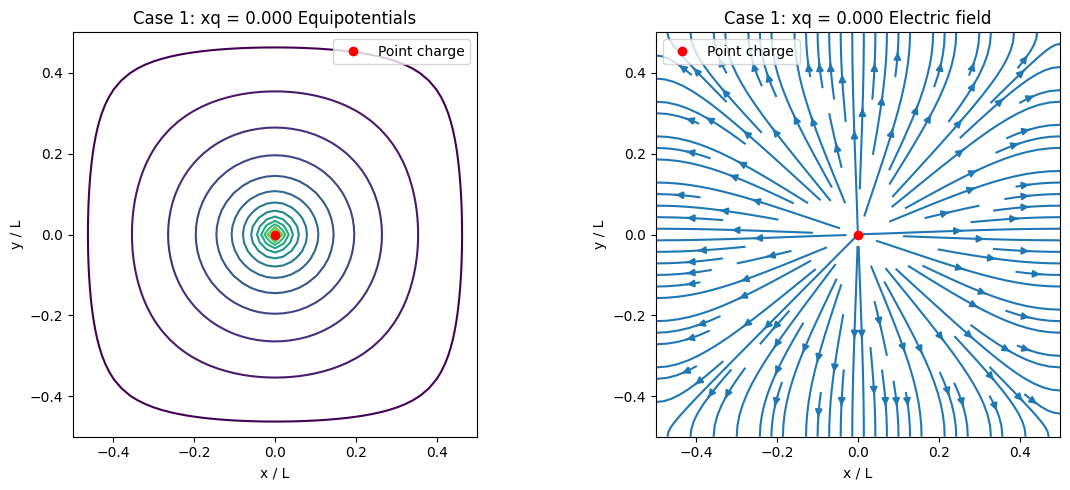

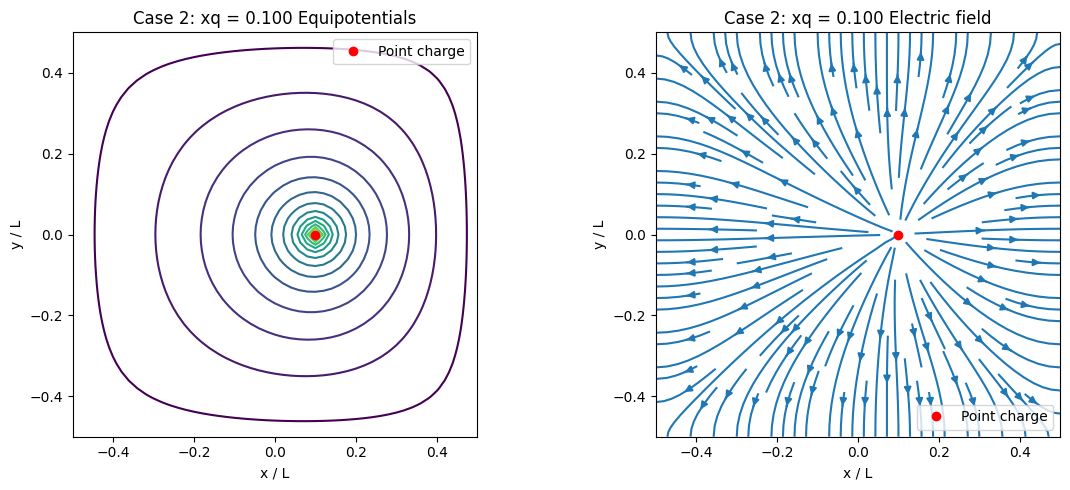

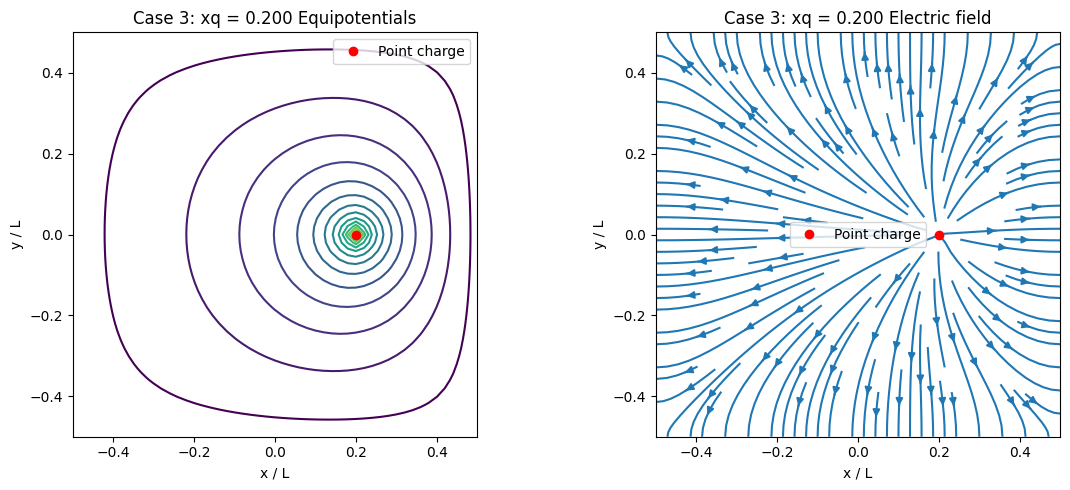

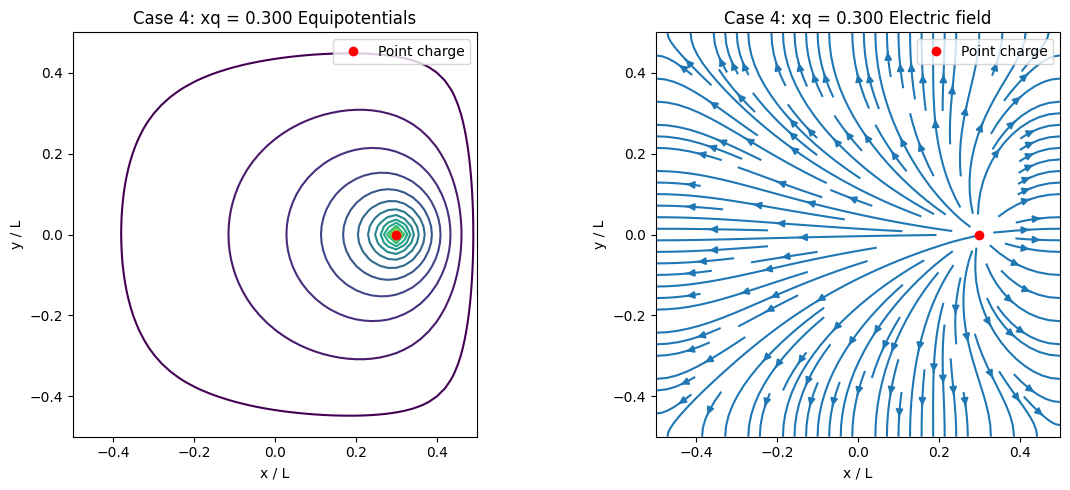

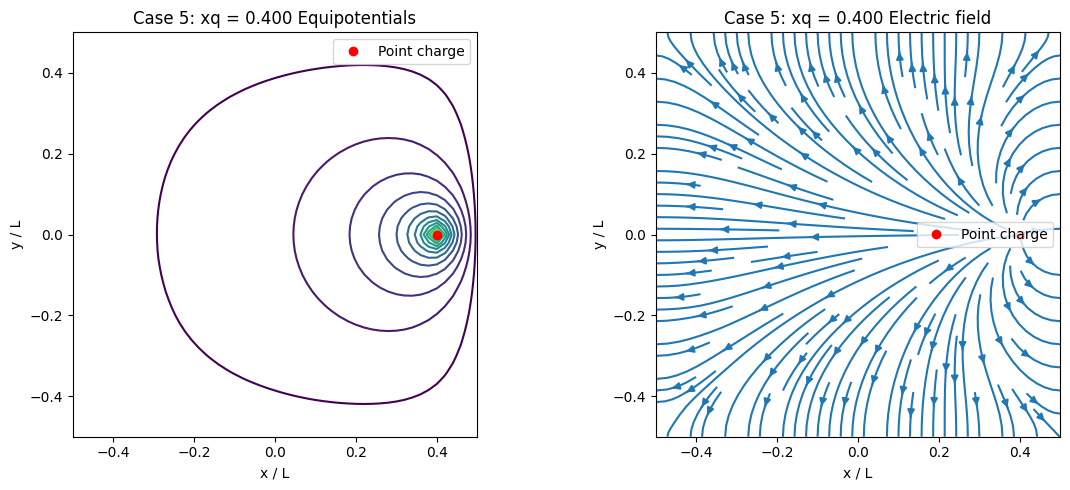

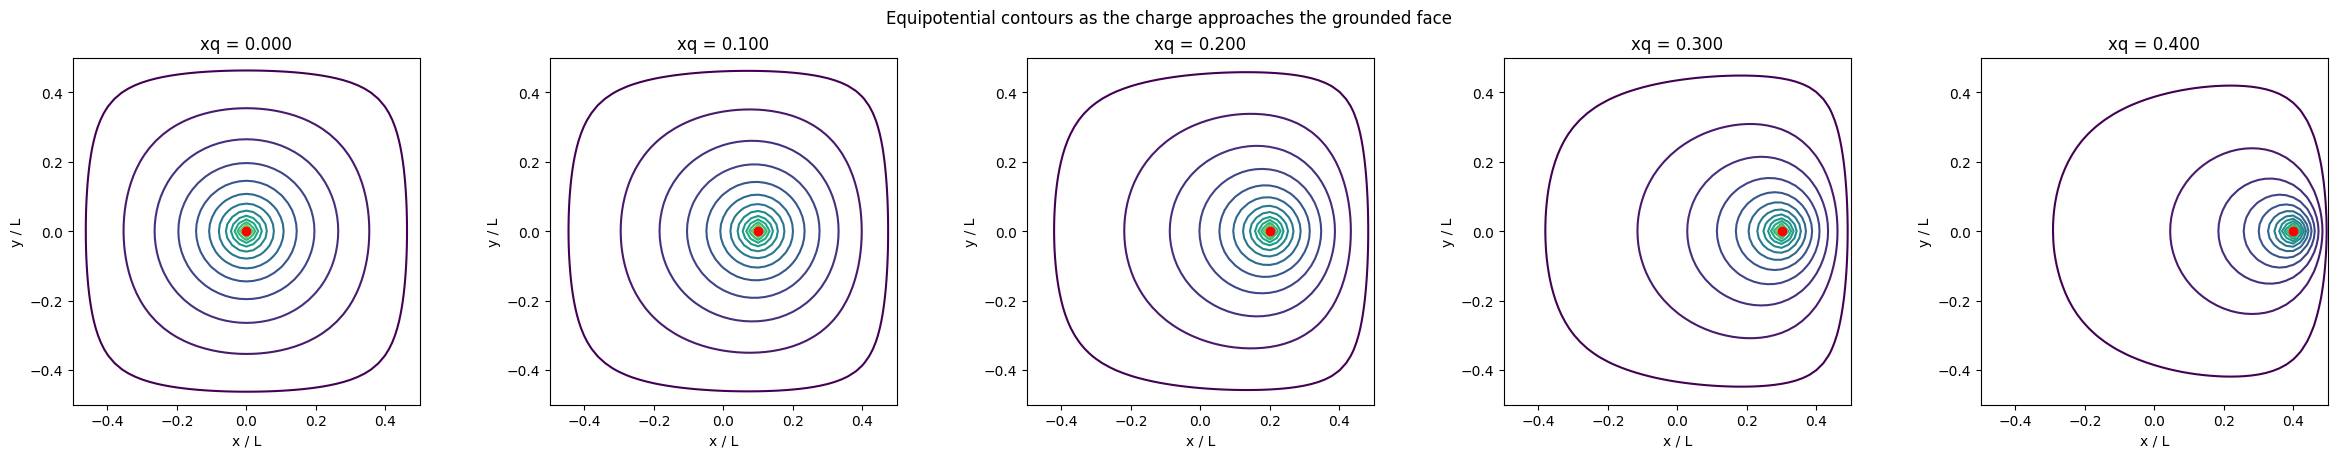


=== Summary ===
As the point charge approaches the grounded wall, the equipotential contours
become increasingly asymmetric and are compressed toward the nearby face.
This reflects the stronger influence of the induced charges on the grounded surface.


In [ ]:
# Problem 2 - PHYS 580 HW
# Point charge in a grounded metal box (2D Poisson solver with SOR)
#
# Task:
#   Extend the point-charge-in-a-box problem by moving the charge near one face
#   of the grounded box, and study how the equipotential contours change.
#
# What this code does:
#   1. Solves Poisson's equation on a square grid with grounded boundaries
#   2. Places a point charge at different x-positions inside the box
#   3. Uses SOR to obtain the potential
#   4. Plots equipotential contours for each case
#   5. Compares how the contours distort as the charge approaches one wall
#
# Numerical method:
#   Poisson equation in 2D:
#       ∇^2 V = -rho/eps0
#
#   Finite-difference update:
#       V_new = (1/4)[neighbors + dL^2 * rho/eps0]
#
#   SOR update:
#       V <- V + alpha * (V_GS - V)
#
# Boundary condition:
#   Outer box boundary is grounded: V = 0
#
# Adequacy:
#   Same convergence threshold for all cases
#   Same grid used for all positions
#   Multiple charge positions used to isolate the effect of wall proximity

import numpy as np
import matplotlib.pyplot as plt
from math import floor, pi


# ------------------------------------------------------------
# Grid and charge setup
# ------------------------------------------------------------
def setup_poisson_grid(dL_in):
    """
    Build square grid over -0.5 <= x,y <= 0.5 with grounded outer boundary.
    """
    M = floor(0.5 / dL_in + 0.5)
    dL = 1.0 / (2 * M)
    N = 2 * M + 1

    xvals = np.array([-0.5 + j * dL for j in range(N)])
    yvals = np.array([-0.5 + i * dL for i in range(N)])
    X, Y = np.meshgrid(xvals, yvals, indexing="xy")

    V = np.zeros((N, N), dtype=float)
    rho = np.zeros((N, N), dtype=float)

    params = {
        "M": M,
        "N": N,
        "dL": dL
    }

    apply_grounded_boundary(V)
    return V, rho, X, Y, params


def apply_grounded_boundary(V):
    V[0, :] = 0.0
    V[-1, :] = 0.0
    V[:, 0] = 0.0
    V[:, -1] = 0.0


def place_point_charge(rho, params, xq, yq, q_over_eps0=1.0):
    """
    Place a point charge on the nearest lattice site.

    We store rho/eps0 effectively through q_over_eps0.
    To represent a point charge on the lattice, put all charge in one cell:
        rho(i,j) = (q/eps0) / dL^2
    so that the source term dL^2 * rho/eps0 entering the update is q/eps0.
    """
    rho[:, :] = 0.0

    M = params["M"]
    dL = params["dL"]

    j = int(round((xq + 0.5) / dL))
    i = int(round((yq + 0.5) / dL))

    # Keep charge off the grounded boundary
    i = max(1, min(2 * M - 1, i))
    j = max(1, min(2 * M - 1, j))

    rho[i, j] = q_over_eps0 / (dL ** 2)

    return i, j


# ------------------------------------------------------------
# SOR solver for Poisson equation
# ------------------------------------------------------------
def alpha_optimal(N):
    return 2.0 / (1.0 + pi / N)


def update_sor_poisson(V, rho, params, alpha):
    ny, nx = V.shape
    dL = params["dL"]

    apply_grounded_boundary(V)

    delta = 0.0
    count = 0

    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            old = V[i, j]

            v_gs = 0.25 * (
                V[i - 1, j] + V[i + 1, j] +
                V[i, j - 1] + V[i, j + 1] +
                (dL ** 2) * rho[i, j]
            )

            V[i, j] = old + alpha * (v_gs - old)

            delta += abs(V[i, j] - old)
            count += 1

    apply_grounded_boundary(V)
    delta /= max(count, 1)
    return delta


def solve_poisson_sor(V0, rho, params, acc=1e-5, alpha=None, max_iter=2_000_000):
    V = V0.copy()

    if alpha is None:
        alpha = alpha_optimal(params["N"])

    delta = np.inf
    it = 0

    while delta > acc and it < max_iter:
        delta = update_sor_poisson(V, rho, params, alpha)
        it += 1

    return V, it, delta, alpha


# ------------------------------------------------------------
# Electric field
# ------------------------------------------------------------
def compute_E(V, params):
    dL = params["dL"]

    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)

    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dL)
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dL)

    Ex[:, 0] = -(V[:, 1] - V[:, 0]) / dL
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dL

    Ey[0, :] = -(V[1, :] - V[0, :]) / dL
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dL

    return Ex, Ey


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_case(V, X, Y, Ex, Ey, xq, yq, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Equipotentials
    vmax = np.max(V)
    if vmax <= 0:
        levels = 20
    else:
        levels = np.linspace(0.02 * vmax, 0.95 * vmax, 16)

    axes[0].contour(X, Y, V, levels=levels)
    axes[0].plot(xq, yq, "ro", markersize=6, label="Point charge")
    axes[0].set_title(f"{title_prefix} Equipotentials")
    axes[0].set_xlabel("x / L")
    axes[0].set_ylabel("y / L")
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].legend()

    # Field lines
    axes[1].streamplot(X, Y, Ex, Ey, density=1.2)
    axes[1].plot(xq, yq, "ro", markersize=6, label="Point charge")
    axes[1].set_title(f"{title_prefix} Electric field")
    axes[1].set_xlabel("x / L")
    axes[1].set_ylabel("y / L")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_comparison_contours(X, Y, V_list, positions, title="Equipotential comparison"):
    n = len(V_list)
    fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4.5))

    if n == 1:
        axes = [axes]

    for ax, V, (xq, yq) in zip(axes, V_list, positions):
        vmax = np.max(V)
        if vmax <= 0:
            levels = 20
        else:
            levels = np.linspace(0.02 * vmax, 0.95 * vmax, 16)

        ax.contour(X, Y, V, levels=levels)
        ax.plot(xq, yq, "ro", markersize=6)
        ax.set_title(f"xq = {xq:.3f}")
        ax.set_xlabel("x / L")
        ax.set_ylabel("y / L")
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Study multiple charge positions
# ------------------------------------------------------------
def run_position_study(dL_in, x_positions, yq=0.0, q_over_eps0=1.0, acc=1e-5):
    V0, rho, X, Y, params = setup_poisson_grid(dL_in)

    results = []

    print("\n=== Point charge near grounded face study ===")
    print("xq\tgrid_x\titerations\tfinal |ΔV|\talpha")

    for xq in x_positions:
        Vstart = V0.copy()
        rho[:, :] = 0.0

        i_q, j_q = place_point_charge(rho, params, xq, yq, q_over_eps0=q_over_eps0)
        Vsol, iters, delta, alpha = solve_poisson_sor(Vstart, rho, params, acc=acc)

        xq_grid = -0.5 + j_q * params["dL"]

        print(f"{xq:.4f}\t{xq_grid:.4f}\t{iters}\t\t{delta:.3e}\t{alpha:.5f}")

        results.append({
            "xq_input": xq,
            "xq_grid": xq_grid,
            "yq": yq,
            "V": Vsol.copy(),
            "iters": iters,
            "delta": delta,
            "alpha": alpha
        })

    return X, Y, params, results


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if __name__ == "__main__":
    print("Problem 2: Point charge near one face of a grounded metal box\n")

    dL_in = float(input("Grid spacing dL (e.g. 0.02): "))
    acc = float(input("Convergence threshold acc (e.g. 1e-5): "))
    q_over_eps0 = float(input("Charge strength q/eps0 (e.g. 1.0): "))

    print("\nChoose charge x-positions inside the box, moving toward the right wall at x = +0.5.")
    print("Suggested set: 0.00, 0.20, 0.30, 0.40")
    x_string = input("Enter x-positions separated by commas: ")

    x_positions = [float(s.strip()) for s in x_string.split(",")]
    yq = 0.0

    X, Y, params, results = run_position_study(
        dL_in=dL_in,
        x_positions=x_positions,
        yq=yq,
        q_over_eps0=q_over_eps0,
        acc=acc
    )

    # Plot one full case at a time
    for k, res in enumerate(results, start=1):
        V = res["V"]
        xq = res["xq_grid"]
        yq = res["yq"]
        Ex, Ey = compute_E(V, params)

        title_prefix = f"Case {k}: xq = {xq:.3f}"
        plot_case(V, X, Y, Ex, Ey, xq, yq, title_prefix=title_prefix)

    # Comparison figure: equipotentials only
    V_list = [res["V"] for res in results]
    pos_list = [(res["xq_grid"], res["yq"]) for res in results]

    plot_comparison_contours(
        X, Y, V_list, pos_list,
        title="Equipotential contours as the charge approaches the grounded face"
    )

    print("\n=== Summary ===")
    print("As the point charge approaches the grounded wall, the equipotential contours")
    print("become increasingly asymmetric and are compressed toward the nearby face.")
    print("This reflects the stronger influence of the induced charges on the grounded surface.")

In [ ]:
# Problem 2 - SNIPPETS

def place_point_charge(rho, params, xq, yq, q_over_eps0 = 1.0):
    rho[:, :] = 0.0;
    M = params["M"];
    dL = params["dL"];

    j = int(round((xq + 0.5) / dL));
    i = int(round((yq + 0.5) / dL));
    # Keep charge off the grounded boundary
    i = max(1, min(2 * M - 1, i));
    j = max(1, min(2 * M - 1, j));

    rho[i, j] = q_over_eps0 / (dL ** 2);

    return i, j;


def update_sor_poisson(V, rho, params, alpha):
    ny, nx = V.shape;
    dL = params["dL"];
    apply_grounded_boundary(V);

    delta = 0.0;
    count = 0;
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            old = V[i, j];
            v_gs = 0.25 * (V[i - 1, j] + V[i + 1, j] + V[i, j - 1] + V[i, j + 1] + (dL ** 2) * rho[i, j]);
            V[i, j] = old + alpha * (v_gs - old);

            delta += abs(V[i, j] - old)
            count += 1;

    apply_grounded_boundary(V);
    delta /= max(count, 1);
    return delta;


def solve_poisson_sor(V0, rho, params, acc = 1e-5, alpha = None, max_iter = 2_000_000):
    V = V0.copy();

    if alpha is None:
        alpha = alpha_optimal(params["N"]);

    delta = np.inf;
    it = 0;
    while delta > acc and it < max_iter:
        delta = update_sor_poisson(V, rho, params, alpha);
        it += 1;

    return V, it, delta, alpha;



def run_position_study(dL_in, x_positions, yq=0.0, q_over_eps0=1.0, acc=1e-5):
    V0, rho, X, Y, params = setup_poisson_grid(dL_in)
    results = []
    print("\n=== Point charge near grounded face study ===");
    print("xq\tgrid_x\titerations\tfinal |ΔV|\talpha");

    for xq in x_positions:
        Vstart = V0.copy();
        rho[:, :] = 0.0;

        i_q, j_q = place_point_charge(rho, params, xq, yq, q_over_eps0 = q_over_eps0);
        Vsol, iters, delta, alpha = solve_poisson_sor(Vstart, rho, params, acc = acc);
        xq_grid = -0.5 + j_q * params["dL"];

        print(f"{xq:.4f}\t{xq_grid:.4f}\t{iters}\t\t{delta:.3e}\t{alpha:.5f}");
        results.append({"xq_input": xq, "xq_grid": xq_grid, "yq": yq, "V": Vsol.copy(), "iters": iters, "delta": delta,"alpha": alpha});

    return X, Y, params, results

Problem 3: Straight-wire magnetic field
Compare rectangular summation with Simpson's rule for the same dz.

Half-length of wire Lwire (e.g. 5.0): 5.0
Representative grid spacing dz (e.g. 0.2): 0.2
Minimum x for B(x) plot (e.g. 0.2): 0.2
Maximum x for B(x) plot (e.g. 2.0): 2.0
Number of x points for B(x) plot (e.g. 10): 10
Single x value for error-vs-dz study (e.g. 1.0): 1.0

=== Representative B(x) comparison ===
x	Rectangular	Simpson		Exact(finite wire)
0.2000	10.11635243	10.82879653	9.99200959
0.4000	4.98422326	5.00490754	4.98407639
0.6000	3.30957119	3.31030629	3.30958946
0.8000	2.46857756	2.46862811	2.46860158
1.0000	1.96113235	1.96116232	1.96116135
1.2000	1.62061214	1.62064548	1.62064550
1.4000	1.37562581	1.37566282	1.37566289
1.6000	1.19049007	1.19053012	1.19053018
1.8000	1.04538800	1.04543039	1.04543046
2.0000	0.92843255	0.92847663	0.92847669


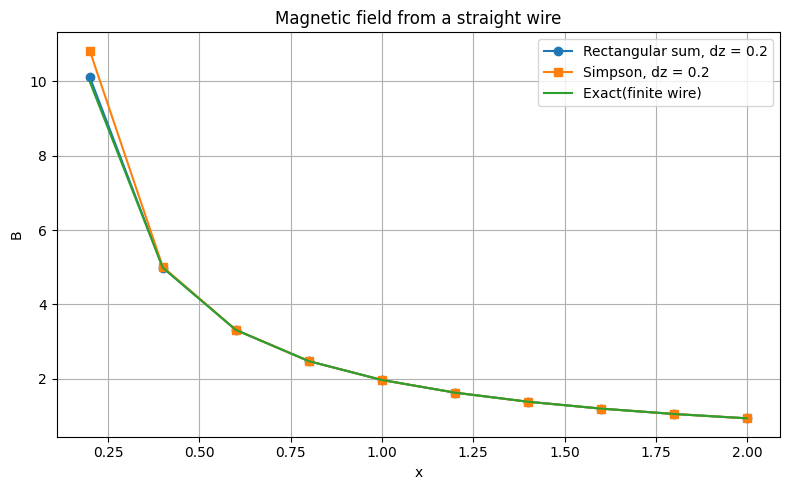


=== Error study at fixed x ===
x_test = 1.0000, Exact(finite wire) = 1.96116135

dz	Rectangular	Simpson		|Rect-Exact|	|Simp-Exact|
0.5000	1.96104435	1.95295437	1.17000874e-04	8.20698531e-03
0.4000	1.96104246	1.96257649	1.18888694e-04	1.41513389e-03
0.3000	1.96264764	1.96129083	1.48628512e-03	1.29480286e-04
0.2000	1.96113235	1.96116232	2.89974048e-05	9.66358172e-07
0.1500	1.96153313	1.96116133	3.71776935e-04	2.03096480e-08
0.1000	1.96115410	1.96116135	7.25194868e-06	3.46332096e-09
0.0800	1.96115671	1.96116135	4.64144686e-06	1.37486156e-09
0.0500	1.96115954	1.96116135	1.81314971e-06	2.16722862e-10


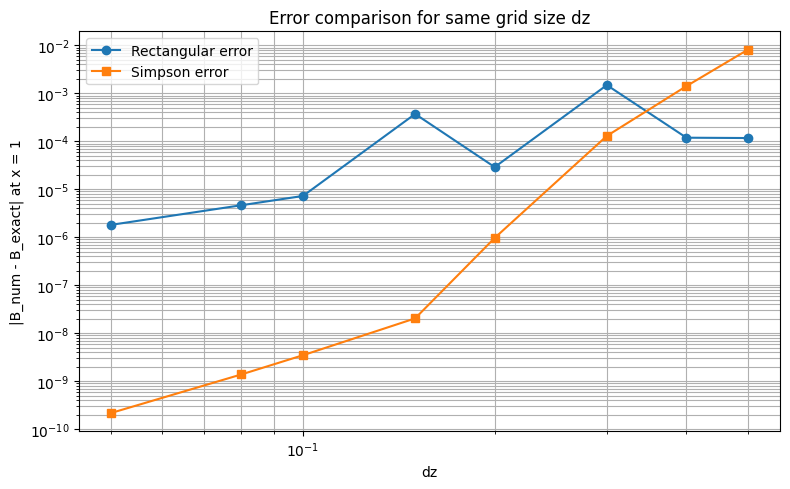


Done.


In [ ]:
# Problem 3 - PHYS 580 HW
# Magnetic field from a straight wire:
# comparison of Eq. (5.25) rectangular summation vs Simpson's rule
#
# Task:
#   Calculate the magnetic field from a straight wire of current using
#   Simpson's rule, and compare it with the result obtained from Eq. (5.25)
#   for the same grid size Δz.
#
# What this code does:
#   1. Computes B(x) from a finite straight wire along the z-axis
#   2. Uses two numerical integration methods with the same Δz:
#        - rectangular summation (Eq. 5.25 style)
#        - Simpson's rule
#   3. Compares both methods against the exact infinite-wire result
#   4. Makes:
#        - a representative B(x) plot
#        - an error-vs-Δz plot
#   5. Prints a comparison table
#
# Geometry:
#   Straight wire lies along the z-axis from z = -Lwire to z = +Lwire
#   Field is evaluated in the x-z plane at points (x, 0, 0)
#
# Units:
#   We set mu0 I / (4 pi) = 1, so the exact infinite-wire result is
#       B_exact(x) = 2 / x
#
# Notes:
#   - Simpson's rule requires an even number of subintervals.
#   - The same Δz is used for both methods.
#   - For a sufficiently long wire, the finite-wire result should approach
#     the infinite-wire result except very near the wire.

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Integrand for straight-wire Biot-Savart law
# ------------------------------------------------------------
def integrand(z, x):
    """
    For a straight wire along z-axis, evaluated at (x, 0, 0),
    the magnetic field magnitude is proportional to

        ∫ dz * x / (x^2 + z^2)^(3/2)

    with prefactor mu0 I / (4 pi), which we set to 1.
    """
    return x / (x**2 + z**2)**1.5


# ------------------------------------------------------------
# Rectangular-rule version of Eq. (5.25)
# ------------------------------------------------------------
def B_rectangular(x, Lwire, dz):
    """
    Left-endpoint rectangular summation with step size dz.
    Uses the same grid spacing convention as the comparison.
    """
    z = np.arange(-Lwire, Lwire, dz)
    return np.sum(integrand(z, x)) * dz


# ------------------------------------------------------------
# Simpson's rule
# ------------------------------------------------------------
def B_simpson(x, Lwire, dz):
    """
    Simpson's rule on [-Lwire, Lwire] with grid size as close as possible
    to dz, while enforcing an even number of subintervals.
    """
    length = 2.0 * Lwire
    n = int(round(length / dz))

    # Simpson requires even n
    if n % 2 == 1:
        n += 1
    if n < 2:
        n = 2

    dz_eff = length / n
    z = np.linspace(-Lwire, Lwire, n + 1)
    f = integrand(z, x)

    S = f[0] + f[-1] + 4.0 * np.sum(f[1:-1:2]) + 2.0 * np.sum(f[2:-1:2])
    return (dz_eff / 3.0) * S


# ------------------------------------------------------------
# Exact infinite-wire result in these units
# ------------------------------------------------------------
def B_finite_wire_exact(x, Lwire):
    return 2.0 * Lwire / (x * np.sqrt(x**2 + Lwire**2))


# ------------------------------------------------------------
# Compute B(x) curves for one chosen dz
# ------------------------------------------------------------
def compute_B_curves(x_values, Lwire, dz):
    B_rect = np.array([B_rectangular(x, Lwire, dz) for x in x_values])
    B_simp = np.array([B_simpson(x, Lwire, dz) for x in x_values])
    B_exact = np.array([B_finite_wire_exact(x, Lwire) for x in x_values])
    return B_rect, B_simp, B_exact


# ------------------------------------------------------------
# Error study versus dz
# ------------------------------------------------------------
def error_study(x_test, Lwire, dz_list):
    rect_vals = []
    simp_vals = []
    exact = B_finite_wire_exact(x_test, Lwire)

    for dz in dz_list:
        rect_vals.append(B_rectangular(x_test, Lwire, dz))
        simp_vals.append(B_simpson(x_test, Lwire, dz))

    rect_vals = np.array(rect_vals)
    simp_vals = np.array(simp_vals)

    rect_err = np.abs(rect_vals - exact)
    simp_err = np.abs(simp_vals - exact)

    return rect_vals, simp_vals, rect_err, simp_err, exact


# ------------------------------------------------------------
# Plot representative B(x) comparison
# ------------------------------------------------------------
def plot_B_comparison(x_values, B_rect, B_simp, B_exact, dz):
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, B_rect, "o-", label=f"Rectangular sum, dz = {dz:g}")
    plt.plot(x_values, B_simp, "s-", label=f"Simpson, dz = {dz:g}")
    plt.plot(x_values, B_exact, "-", label="Exact(finite wire)")

    plt.xlabel("x")
    plt.ylabel("B")
    plt.title("Magnetic field from a straight wire")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Plot error vs dz
# ------------------------------------------------------------
def plot_error_vs_dz(dz_list, rect_err, simp_err, x_test):
    plt.figure(figsize=(8, 5))
    plt.loglog(dz_list, rect_err, "o-", label="Rectangular error")
    plt.loglog(dz_list, simp_err, "s-", label="Simpson error")

    plt.xlabel("dz")
    plt.ylabel(f"|B_num - B_exact| at x = {x_test:g}")
    plt.title("Error comparison for same grid size dz")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if __name__ == "__main__":
    print("Problem 3: Straight-wire magnetic field")
    print("Compare rectangular summation with Simpson's rule for the same dz.\n")

    Lwire = float(input("Half-length of wire Lwire (e.g. 5.0): "))
    dz_rep = float(input("Representative grid spacing dz (e.g. 0.2): "))
    x_min = float(input("Minimum x for B(x) plot (e.g. 0.2): "))
    x_max = float(input("Maximum x for B(x) plot (e.g. 2.0): "))
    nx = int(input("Number of x points for B(x) plot (e.g. 10): "))
    x_test = float(input("Single x value for error-vs-dz study (e.g. 1.0): "))

    # Representative B(x) comparison
    x_values = np.linspace(x_min, x_max, nx)
    B_rect, B_simp, B_exact = compute_B_curves(x_values, Lwire, dz_rep)

    print("\n=== Representative B(x) comparison ===")
    print("x\tRectangular\tSimpson\t\tExact(finite wire)")
    for x, br, bs, be in zip(x_values, B_rect, B_simp, B_exact):
        print(f"{x:.4f}\t{br:.8f}\t{bs:.8f}\t{be:.8f}")

    plot_B_comparison(x_values, B_rect, B_simp, B_exact, dz_rep)

    # Error study with same dz values for both methods
    dz_list = np.array([0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.08, 0.05], dtype=float)
    rect_vals, simp_vals, rect_err, simp_err, exact_val = error_study(x_test, Lwire, dz_list)

    print("\n=== Error study at fixed x ===")
    print(f"x_test = {x_test:.4f}, Exact(finite wire) = {exact_val:.8f}\n")
    print("dz\tRectangular\tSimpson\t\t|Rect-Exact|\t|Simp-Exact|")
    for dz, br, bs, er, es in zip(dz_list, rect_vals, simp_vals, rect_err, simp_err):
        print(f"{dz:.4f}\t{br:.8f}\t{bs:.8f}\t{er:.8e}\t{es:.8e}")

    plot_error_vs_dz(dz_list, rect_err, simp_err, x_test)

    print("\nDone.")

In [ ]:
# Problem 3 - SNIPPETS


def integrand(z, x):
    return x / (x**2 + z**2)**1.5;


def B_rectangular(x, Lwire, dz):
    z = np.arange(-Lwire, Lwire, dz);
    return np.sum(integrand(z, x)) * dz;


def B_simpson(x, Lwire, dz):
    length = 2.0 * Lwire;
    n = int(round(length / dz));

    # Simpson requires even n
    if n % 2 == 1:
        n += 1;
    if n < 2:
        n = 2;

    dz_eff = length / n;
    z = np.linspace(-Lwire, Lwire, n + 1);
    f = integrand(z, x);

    S = f[0] + f[-1] + 4.0 * np.sum(f[1:-1:2]) + 2.0 * np.sum(f[2:-1:2]);
    return (dz_eff / 3.0) * S;


def B_finite_wire_exact(x, Lwire):
    return 2.0 * Lwire / (x * np.sqrt(x**2 + Lwire**2));


def error_study(x_test, Lwire, dz_list):
    rect_vals = [];
    simp_vals = [];
    exact = B_finite_wire_exact(x_test, Lwire);

    for dz in dz_list:
        rect_vals.append(B_rectangular(x_test, Lwire, dz));
        simp_vals.append(B_simpson(x_test, Lwire, dz));

    rect_vals = np.array(rect_vals);
    simp_vals = np.array(simp_vals);

    rect_err = np.abs(rect_vals - exact);
    simp_err = np.abs(simp_vals - exact);

    return rect_vals, simp_vals, rect_err, simp_err, exact;
